In [117]:
# ============================================================
# Development settings
# ============================================================
%load_ext autoreload
%autoreload 2

# ============================================================
# Standard library
# ============================================================
import os
import sys
from pathlib import Path
import matplotlib.colors as mcolors
import colorcet as cc
# Add project root to Python path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

# ============================================================
# Scientific / geospatial libraries
# ============================================================
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from shapely.geometry import Point
import hydromt
from hydromt_sfincs import SfincsModel
from itertools import product

# ============================================================
# Project modules
# ============================================================
from src.terrain_transformation import (
    DEM_resampling,
    add_raster_to_yml,
    change_yml_root,
    modify_DEM
)

from src.plotting_function import (
    extract_profiles_from_tif,
    profile_check
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [118]:
plt.rcParams.update({
    "font.size": 12,          # Default font size
    "axes.titlesize": 14,     # Axes title
    "axes.labelsize": 12,     # X/Y labels
    "xtick.labelsize": 14,    # X tick labels
    "ytick.labelsize": 14,    # Y tick labels
    "legend.fontsize": 11,    # Legend
    "figure.titlesize": 16,   # Figure title
})

In [119]:
DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "figures"
catalog_path = DATA_DIR / 'model_terrain.yml'
data_catalog = hydromt.DataCatalog(data_libs=[catalog_path])
base_model_root = DATA_DIR / "base_model"
input_file = DATA_DIR / "model_input"
MODEL_ROOT = PROJECT_ROOT /'model'

print("Project root:", PROJECT_ROOT)
print("Data:", DATA_DIR)
print("Figures:", FIGURE_DIR)
print("Data Catalog:", catalog_path)
print("Base Model:", base_model_root)
print("Model root:", MODEL_ROOT)

2026-08-25 17:18:59,602 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from f:\TUD_CEG_Repository\MSc_Thesis\coastal-multi-hazard-amplification\data\model_terrain.yml
Project root: f:\TUD_CEG_Repository\MSc_Thesis\coastal-multi-hazard-amplification
Data: f:\TUD_CEG_Repository\MSc_Thesis\coastal-multi-hazard-amplification\data
Figures: f:\TUD_CEG_Repository\MSc_Thesis\coastal-multi-hazard-amplification\figures
Data Catalog: f:\TUD_CEG_Repository\MSc_Thesis\coastal-multi-hazard-amplification\data\model_terrain.yml
Base Model: f:\TUD_CEG_Repository\MSc_Thesis\coastal-multi-hazard-amplification\data\base_model
Model root: f:\TUD_CEG_Repository\MSc_Thesis\coastal-multi-hazard-amplification\model


wrapper function

In [120]:
def initilize_process(base_model_path,catalog_path,location):
    # read base model config and get region
    model = SfincsModel(
        root=base_model_path,
        mode="r",  
        )
    model.read()
    model_region=model.region

    with rasterio.open(input_dem) as src:
        epsg = src.crs.to_epsg()

    # change the catalog root so it reproducible on other machine
    change_yml_root(
        yml_path=catalog_path,
        new_root=TERRAIN_DIR,
    )

    # resampling base dem and add it into data catalog
    DEM_resampling(input_dem,out_dir,location,scale=10)
    add_raster_to_yml(
        yml_path=catalog_path,
        dataset_name=f'{location}_10m',
        file_path=f'{location}/{location}_10m.tif',
        crs=epsg,
    )



    return epsg, model_region

In [121]:
def DEM_modification_wrapper(location,model_region,epsg,nyears):
    for nyear, erosion, subsidence in product(
        nyears,
        [False, True],
        [False, True],
    ):
        if not erosion and not subsidence:
            continue

        if erosion:
            string = 'erosion'
            out_name = f'{location}_{string}_{nyear}'

        if subsidence:
            string = 'subsidence'
            out_name = f'{location}_{string}_{nyear}'

        if erosion & subsidence:
            string1 = 'erosion'
            string2 = 'subsidence'
            out_name = f'{location}_{string1}_{string2}_{nyear}'

        print(out_name)

        # read resampled dem
        data_catalog.get_source(f'{location}_10m')
        da = data_catalog.get_rasterdataset(f'{location}_10m').rename("dep").to_dataset()

        dep_old, dep_new = modify_DEM(da, model_region,
                                erosion=True,subsidence=True,
                                nyear=100,resolution=10,resample=10,
                                gctr_file = gctr_file,
                                coastline_file = coastline_file,
                                retreat_limit_file = retreat_limit_file,
                                performed_manual_edit = True,
                                subsidence_file=subsidence_file)

        da.dep.values = dep_new
        da = da.compute()
        da.raster.set_crs(da.raster.crs)
        da.dep.raster.to_raster(TERRAIN_DIR / f"{location}/{out_name}.tif")

        add_raster_to_yml(
        yml_path=catalog_path,
        dataset_name=out_name,
        file_path=f'{location}/{out_name}.tif',
        crs=epsg,
        )

Bohai terrain modification

In [122]:
location = 'bohai'
base_model = next(x for x in os.listdir(base_model_root) if location in x.lower())
base_model_path = base_model_root / base_model

In [123]:
input_dem = base_model_path / "gis/dep.tif"
TERRAIN_DIR = DATA_DIR / f'transformed_terrain'
out_dir = TERRAIN_DIR / f'{location}'


# terrain change information
gctr_file = input_file / f'{location}/{location}_gctr.parquet'
coastline_file = input_file / f'{location}/{location}_coastline.geojson'
retreat_limit_file = input_file / f'{location}/{location}_retreat_limit.geojson'
subsidence_file = DATA_DIR / 'Subsidence/Final_subsidence_prediction.tif'



In [124]:
nyears = [50, 100]

epsg, model_region = initilize_process(base_model_path,catalog_path,location)
DEM_modification_wrapper(location,model_region,epsg,nyears)

2026-08-25 17:19:00,473 - hydromt.model.model - model - INFO - Initializing sfincs model from hydromt_sfincs (v2.0.0rc1).
2026-08-25 17:19:00,474 - hydromt.model.model - model - WARNING - No region component found in components.
2026-08-25 17:19:00,715 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: mask
2026-08-25 17:19:00,717 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: dep
2026-08-25 17:19:00,718 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: manning
2026-08-25 17:19:00,798 - hydromt.hydromt_sfincs.components.output - output - WARNING - File F:\TUD_CEG_Repository\MSc_Thesis\coastal-multi-hazard-amplification\data\base_model\bohai_noveg\sfincs_map.nc not found.
2026-08-25 17:19:00,799 - hydromt.hydromt_sfincs.components.output - output - WARNING - File F:\TUD_CEG_Repository\MSc_Thesis\coastal-multi-hazard-amplification\data\base_model\bohai_noveg\sfincs_his.nc not found.
bohai_subsidence_50
2026-08-25 17:19:01,4

checking the data for bohai

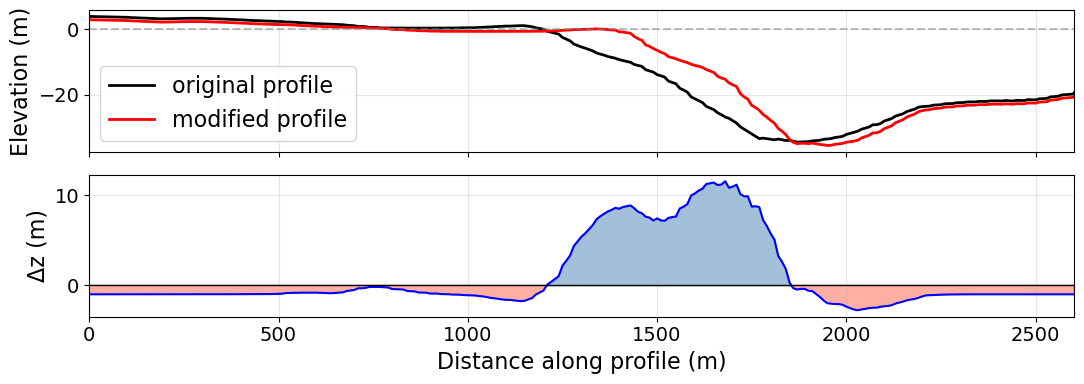

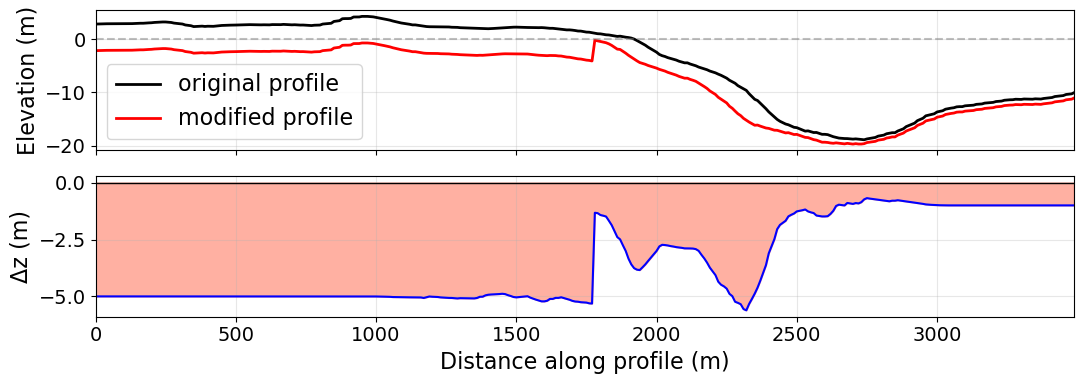

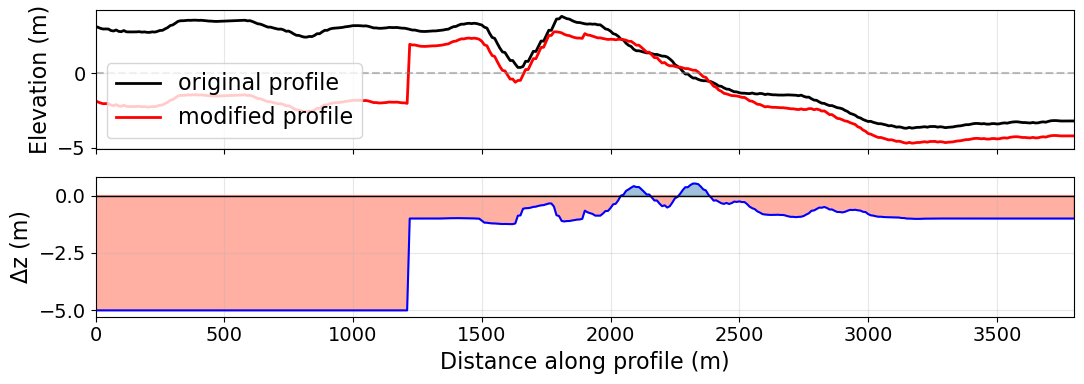

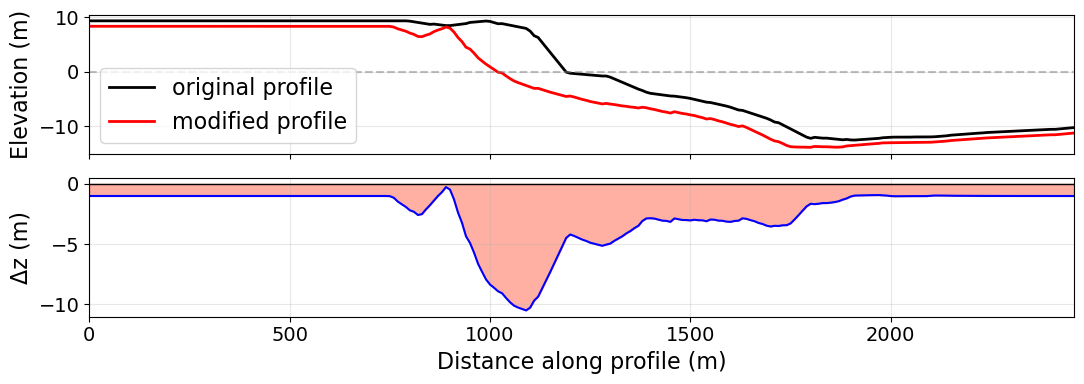

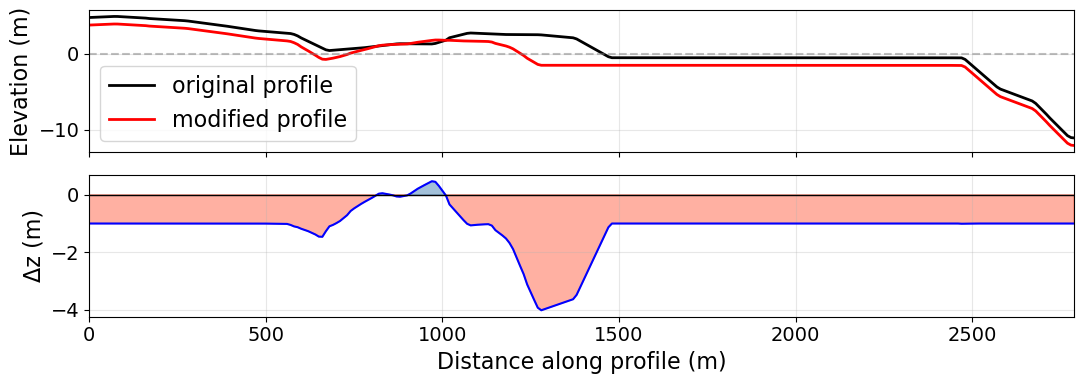

In [125]:
base_dem = TERRAIN_DIR / f'{location}/{location}_10m.tif'
mmodified_dem = TERRAIN_DIR / f'{location}/{location}_erosion_subsidence_100.tif'
profile_file = input_file / f'{location}/{location}_profiles.geojson'

base_profiles = extract_profiles_from_tif(
    tif_path=base_dem,
    geojson_path=profile_file,
    spacing=10,
    # id_col="id",   # or None
)

modified_profiles = extract_profiles_from_tif(
    tif_path=mmodified_dem,
    geojson_path=profile_file,
    spacing=10,
    # id_col="id",   # or None
)

for pid in range(base_profiles['profile_id'].nunique()):
    _ = profile_check(
        base_profiles,
        modified_profiles,
        profile_id=pid,
        part_id=0,
        direction="left"
    )

Mozambique terrain modification

In [126]:
location = 'mozambique'
base_model = next(x for x in os.listdir(base_model_root) if location in x.lower())
base_model_path = base_model_root / base_model

In [127]:
input_dem = base_model_path / "gis/dep.tif"
TERRAIN_DIR = DATA_DIR / f'transformed_terrain'
out_dir = TERRAIN_DIR / f'{location}'


# terrain change information
gctr_file = input_file / f'{location}/{location}_gctr.parquet'
coastline_file = input_file / f'{location}/{location}_coastline.geojson'
retreat_limit_file = input_file / f'{location}/{location}_retreat_limit.geojson'
subsidence_file = DATA_DIR / 'Subsidence/Final_subsidence_prediction.tif'



In [128]:

nyears = [50, 100]

epsg, model_region = initilize_process(base_model_path,catalog_path,location)
DEM_modification_wrapper(location,model_region,epsg,nyears)


2026-08-25 17:20:24,857 - hydromt.model.model - model - INFO - Initializing sfincs model from hydromt_sfincs (v2.0.0rc1).
2026-08-25 17:20:24,858 - hydromt.model.model - model - WARNING - No region component found in components.
2026-08-25 17:20:25,237 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: mask
2026-08-25 17:20:25,238 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: dep
2026-08-25 17:20:25,239 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: manning
2026-08-25 17:20:25,322 - hydromt.hydromt_sfincs.components.output - output - WARNING - File F:\TUD_CEG_Repository\MSc_Thesis\coastal-multi-hazard-amplification\data\base_model\mozambique_noveg\sfincs_map.nc not found.
2026-08-25 17:20:25,323 - hydromt.hydromt_sfincs.components.output - output - WARNING - File F:\TUD_CEG_Repository\MSc_Thesis\coastal-multi-hazard-amplification\data\base_model\mozambique_noveg\sfincs_his.nc not found.
mozambique_subsidence_50
2026-0

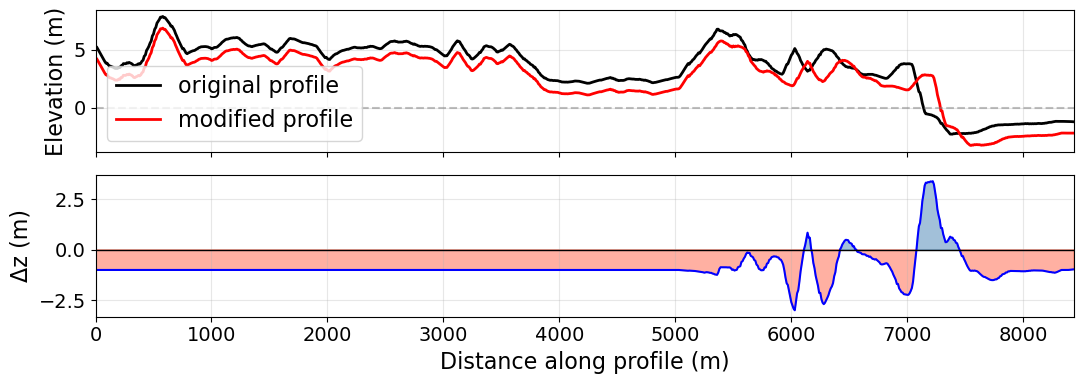

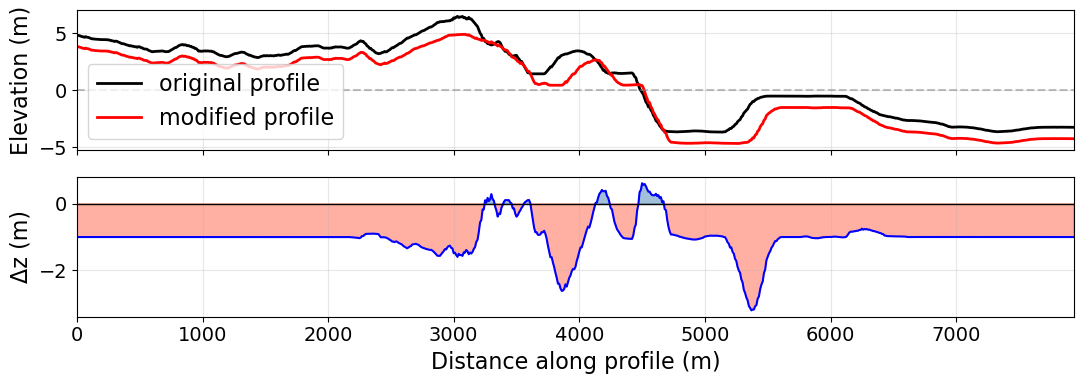

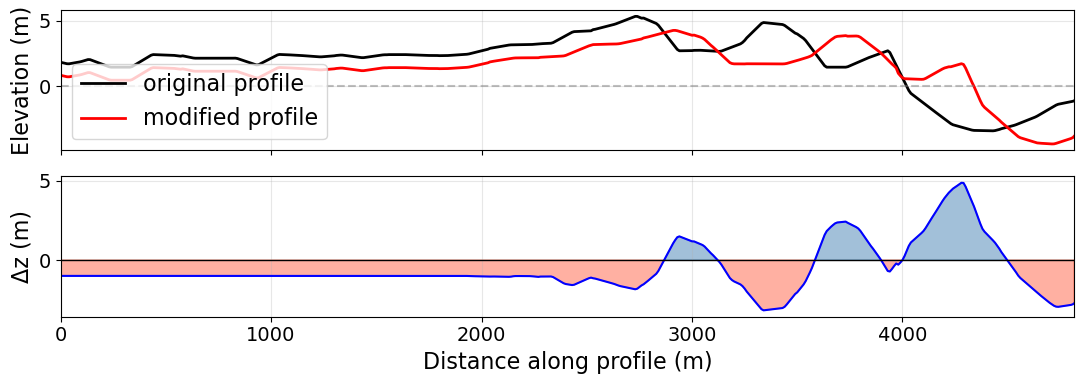

In [129]:
base_dem = TERRAIN_DIR / f'{location}/{location}_10m.tif'
mmodified_dem = TERRAIN_DIR / f'{location}/{location}_erosion_subsidence_100.tif'
profile_file = input_file / f'{location}/{location}_profiles.geojson'


base_profiles = extract_profiles_from_tif(
    tif_path=base_dem,
    geojson_path=profile_file,
    spacing=10,
    # id_col="id",   # or None
)

modified_profiles = extract_profiles_from_tif(
    tif_path=mmodified_dem,
    geojson_path=profile_file,
    spacing=10,
    # id_col="id",   # or None
)

for pid in range(base_profiles['profile_id'].nunique()):
    _ = profile_check(
        base_profiles,
        modified_profiles,
        profile_id=pid,
        part_id=0,
        direction="left"
    )

In [130]:
base_profiles

,profile_id,part_id,distance_m,x,y,value
0,0,0,0.000000,672394.407362,7.757747e+06,5.281026
1,0,0,10.000000,672403.732400,7.757743e+06,5.218036
2,0,0,20.000000,672413.057438,7.757739e+06,5.041873
3,0,0,30.000000,672422.382476,7.757736e+06,4.852293
4,0,0,40.000000,672431.707514,7.757732e+06,4.685607
...,...,...,...,...,...,...
2118,2,0,4780.000000,686472.741657,7.774028e+06,-1.264959
2119,2,0,4790.000000,686482.650274,7.774029e+06,-1.232161
2120,2,0,4800.000000,686492.558891,7.774031e+06,-1.199363
2121,2,0,4810.000000,686502.467508,7.774032e+06,-1.166565
